# Connecting to OMERO at SURF



In [8]:
import ezomero
import matplotlib.pyplot as plt

In [9]:
# Connect
from getpass import getpass

server = 'omero1.fair-omero-lu.src.surf-hosted.nl'
user = 'nlbi'
group = "training"
password = getpass('OMERO password: ')

# Preferred: encrypted Ice connection on port 4064.
# Fallback: unencrypted Ice connection on port 4063. Some corporate networks
# (firewalls / endpoint-security agents doing TLS inspection) silently reset the
# TLS handshake on non-standard ports, which shows up as
# Ice.ConnectionLostException. Port 4063 speaks plain Ice and usually survives.
conn = None
for protocol, port in (('ssl', 4064), ('tcp', 4063)):
    try:
        conn = ezomero.connect(host=f'{protocol}://{server}:{port}', port=port,
                               user=user, password=password, group=group,
                               secure=(protocol == 'ssl'))
    except Exception as e:
        print(f'{protocol}://{server}:{port} failed: {type(e).__name__}: {e}')
        continue
    if conn is not None:
        print(f'Connected over {protocol} on port {port}'
              + ('' if protocol == 'ssl' else '  (unencrypted - fallback)'))
        break

if conn is None:
    raise RuntimeError('Could not connect to OMERO on either port 4064 or 4063')


OMERO password:  ········


Connected over ssl on port 4064


In [10]:
#List screens
screen_ids = ezomero.get_screen_ids(conn)    
for sid in screen_ids:
    screen_name = conn.getObject("Screen", sid).getName()
    print(f'Screen ID: {sid} | Name: {screen_name}')

Screen ID: 1 | Name: nuclei_segmentation


In [11]:
plate_ids = ezomero.get_plate_ids(conn, screen=1)
print(f'Plate IDs: {plate_ids} ')
well_ids = ezomero.get_well_ids(conn,plate=plate_ids[0])
print(f'Well IDs: {well_ids} ')

Plate IDs: [1] 
Well IDs: [24, 2, 7, 9, 3, 19, 14, 15, 1, 22, 21, 20, 13, 23, 10, 18, 4, 16, 11, 12, 17, 5, 8, 6] 


In [12]:
plate = conn.getObject("Plate", plate_ids[0])

# listChildren returns wells unsorted, so sort by grid position
wells = sorted(plate.listChildren(), key=lambda w: (w.getRow(), w.getColumn()))
print(f"{len(wells)} wells")
for well in wells:
    print(well.getId(), well.getWellPos(), "fields:", len(list(well.listChildren())))

24 wells
24 B2 fields: 4
3 B3 fields: 4
1 B4 fields: 4
13 B5 fields: 4
4 B6 fields: 4
17 B7 fields: 4
2 C2 fields: 4
19 C3 fields: 4
22 C4 fields: 4
23 C5 fields: 4
16 C6 fields: 4
5 C7 fields: 4
7 D2 fields: 4
14 D3 fields: 4
21 D4 fields: 4
10 D5 fields: 4
11 D6 fields: 4
8 D7 fields: 4
9 E2 fields: 4
15 E3 fields: 4
20 E4 fields: 4
18 E5 fields: 4
12 E6 fields: 4
6 E7 fields: 4


In [13]:
#get dimensions of one image
well = wells[10]
image = well.getImage(0)          # first field of this well

print(f"{well.getWellPos()} — {image.getName()} (ID {image.getId()})")
print(f"X={image.getSizeX()} Y={image.getSizeY()} Z={image.getSizeZ()} "
      f"C={image.getSizeC()} T={image.getSizeT()} dtype={image.getPixelsType()}")

C6 — 20251111_morphology_XW_plate1406.companion.ome [Well C6, Field #1] (ID 111)
X=1408 Y=1040 Z=1 C=2 T=37 dtype=uint16


In [14]:
z = image.getSizeZ() // 2
c, t = 0, 0

plane = image.getPrimaryPixels().getPlane(theZ=z, theC=c, theT=t)
print("plane shape:", plane.shape, plane.dtype, "range:", plane.min(), plane.max())

plane shape: (1040, 1408) uint16 range: 0 773


In [15]:
z = image.getSizeZ() // 2
c, t = 1, 0

plane = image.getPrimaryPixels().getPlane(theZ=z, theC=c, theT=t)
print("plane shape:", plane.shape, plane.dtype, "range:", plane.min(), plane.max())

plane shape: (1040, 1408) uint16 range: 3 255


In [16]:
#load one plane
z = image.getSizeZ() // 2
c, t = 1, 0

plane = image.getPrimaryPixels().getPlane(theZ=z, theC=c, theT=t)
print("plane shape:", plane.shape, plane.dtype, "range:", plane.min(), plane.max())

plane shape: (1040, 1408) uint16 range: 3 255


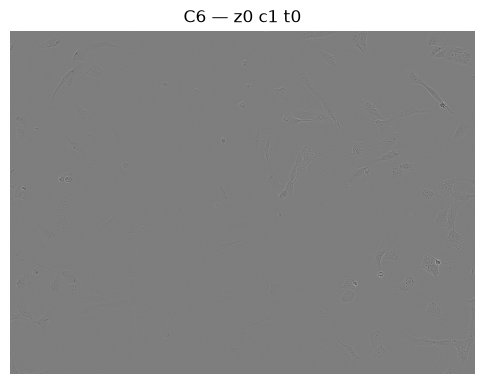

In [17]:
plane_norm = plane / plane.max()
plt.figure(figsize=(6, 6))
plt.imshow(plane_norm, cmap="gray")
plt.title(f"{well.getWellPos()} — z{z} c{c} t{t}")
plt.axis("off")
plt.show()

In [18]:
import ngff_zarr

output_filename = 'output/output.ome.zarr'

multiscales = ngff_zarr.to_multiscales(plane_norm)
ngff_zarr.to_ngff_zarr(output_filename, multiscales)